**1️⃣ 데이터 로드 & 기본 정리**

In [1]:
import os
import json
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["font.size"] = 11

DATA_ROOT = "/data/ephemeral/home/pro-cv-semanticsegmentation-cv-07/src/datasets"

META_XLSX_PATH = os.path.join(DATA_ROOT, "meta_data.xlsx")
EDA_META_PATH  = os.path.join(DATA_ROOT, "eda_metadata.csv")
META_SUB_PATH  = os.path.join(DATA_ROOT, "metadata_with_subject.csv")
OUT_DIR        = os.path.join(DATA_ROOT, "splits")

os.makedirs(OUT_DIR, exist_ok=True)

**2️⃣ subject-level metadata (train + test)**

In [2]:
meta_df = pd.read_excel(META_XLSX_PATH)

meta_df["subject_id"] = meta_df["ID"].apply(lambda x: f"ID{int(x):03d}")

meta_df = meta_df.rename(columns={
    "키(신장)": "height",
    "성별": "sex",
    "나이": "age",
    "체중(몸무게)": "weight",
})

meta_df = meta_df[["subject_id", "height", "sex", "age", "weight"]]

**3️⃣ image-level EDA metadata (train only)**

In [3]:
eda_df = pd.read_csv(EDA_META_PATH)
eda_df["subject_id"] = eda_df["subject_id"].astype(str).str.strip()
eda_df["image_id"]   = eda_df["image_id"].astype(str).str.strip()

**Noise 이미지 제거 (image-level)**

In [4]:
NOISE_IMAGE_IDS = {
    # 네가 정리한 noise image_id
    "image1664935962797.png",
    "image1666661955150.png",
}

eda_df = eda_df[~eda_df["image_id"].isin(NOISE_IMAGE_IDS)]

print("Train images after noise removal:", len(eda_df))

Train images after noise removal: 798


**4️⃣ train / test subject 구분**

In [5]:
train_subject_ids = set(eda_df["subject_id"])

meta_df["split"] = meta_df["subject_id"].apply(
    lambda x: "train" if x in train_subject_ids else "test"
)

**5️⃣ height bin (test 기준 고정)**

In [6]:
NUM_HEIGHT_BINS = 3

test_df = meta_df[meta_df["split"] == "test"].copy()

test_df["height_bin"] = pd.qcut(
    test_df["height"],
    q=NUM_HEIGHT_BINS,
    labels=[f"h{i}" for i in range(NUM_HEIGHT_BINS)]
)

bin_edges = pd.qcut(test_df["height"], q=NUM_HEIGHT_BINS, retbins=True)[1]

meta_df["height_bin"] = pd.cut(
    meta_df["height"],
    bins=bin_edges,
    labels=[f"h{i}" for i in range(NUM_HEIGHT_BINS)],
    include_lowest=True
)

In [7]:
# 🔧 bin 범위 밖 샘플 명시적으로 처리
meta_df["height_bin"] = (
    meta_df["height_bin"]
    .cat.add_categories(["h_out"])
    .fillna("h_out")
)

In [8]:
bin_edges

array([154., 165., 173., 186.])

**6️⃣ wrist deviation / overlap / boundary (subject-level 집계)**

In [25]:
eda_subject_df = (
    eda_df
    .groupby("subject_id")
    .agg({
        "has_wrist_deviation": "max",
        "overlap_pixels": "mean",
        "boundary_adj_pixels": "mean",
        "non_big_bone_pixels": "mean"
    })
    .reset_index()
)

**7️⃣ total_bone_pixels (subject-level 평균)**

In [26]:
meta_sub_df = pd.read_csv(META_SUB_PATH)
meta_sub_df["subject_id"] = meta_sub_df["subject_id"].astype(str).str.strip()

bone_df = (
    meta_sub_df
    .groupby("subject_id")
    .agg({
        "total_bone_pixels": "mean"
    })
    .reset_index()
    .rename(columns={
        "total_bone_pixels": "total_bone_pixels_mean"
    })
)

**8️⃣ train_df 구성 (🔥 핵심)**

In [27]:
train_df = (
    meta_df[meta_df["split"] == "train"]
    .merge(eda_subject_df, on="subject_id", how="left")
    .merge(bone_df, on="subject_id", how="left")
)

train_df["has_wrist_deviation"] = (
    train_df["has_wrist_deviation"]
    .fillna(0)
    .astype(int)
)

**9️⃣ nail art (subject 단위)**

In [28]:
NAIL_SUBJECT_IDS = {
    "ID073", "ID288", "ID387", "ID523", "ID543"
}

train_df["has_nail_art"] = train_df["subject_id"].isin(
    NAIL_SUBJECT_IDS
).astype(int)

**🔟 LAST_METADATA.csv 저장**

In [32]:
LAST_META_PATH = os.path.join(DATA_ROOT, "LAST_METADATA.csv")
train_df.to_csv(LAST_META_PATH, index=False)
print("Saved:", LAST_META_PATH)

Saved: /data/ephemeral/home/pro-cv-semanticsegmentation-cv-07/src/datasets/LAST_METADATA.csv


## **시각화 코드들**

**1️⃣1️⃣ 시각화**

(1-1) wrist deviation vs total bone pixels

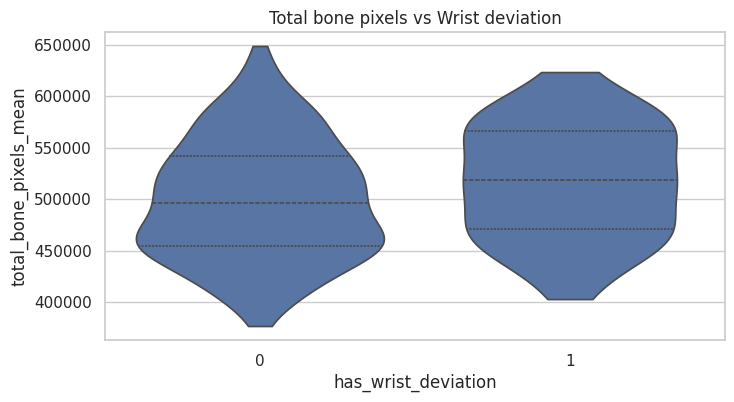

In [30]:
sns.violinplot(
    data=train_df,
    x="has_wrist_deviation",
    y="total_bone_pixels_mean",
    inner="quartile",
    cut=0
)
plt.title("Total bone pixels vs Wrist deviation")
plt.show()

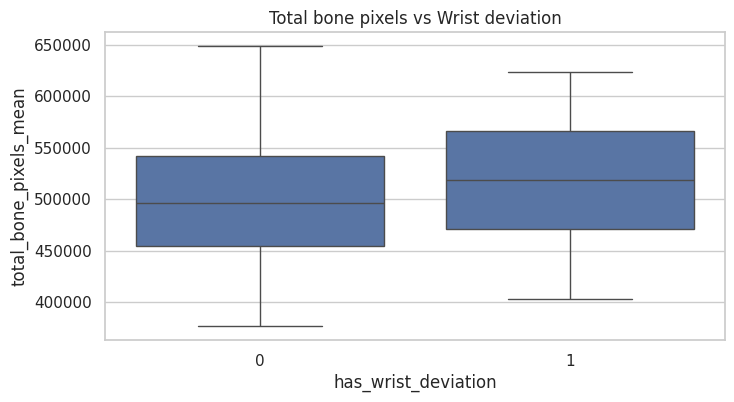

In [33]:
sns.boxplot(
    data=train_df,
    x="has_wrist_deviation",
    y="total_bone_pixels_mean"
)
plt.title("Total bone pixels vs Wrist deviation")
plt.show()

(1-2) wrist deviation vs overlap pixels

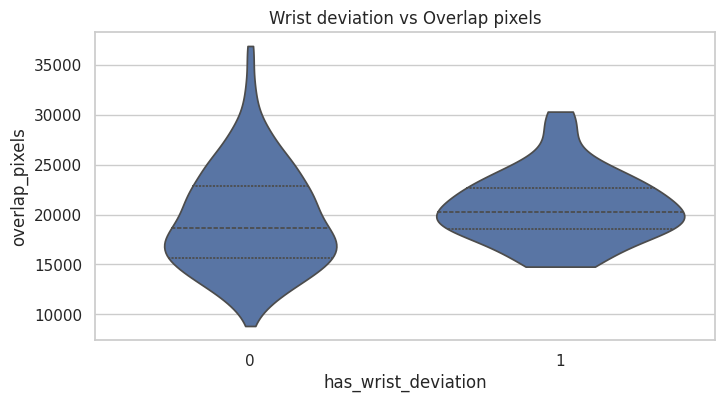

In [34]:
sns.violinplot(
    data=train_df,
    x="has_wrist_deviation",
    y="overlap_pixels",
    inner="quartile",
    cut=0
)
plt.title("Wrist deviation vs Overlap pixels")
plt.show()

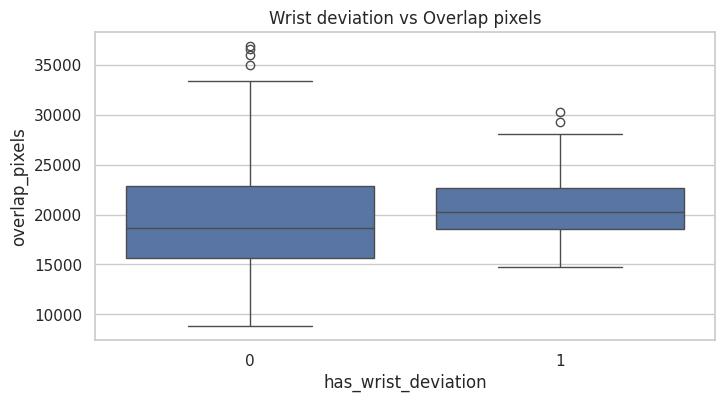

In [35]:
sns.boxplot(
    data=train_df,
    x="has_wrist_deviation",
    y="overlap_pixels"
)
plt.title("Wrist deviation vs Overlap pixels")
plt.show()

(2) height_bin vs total_bone_pixels

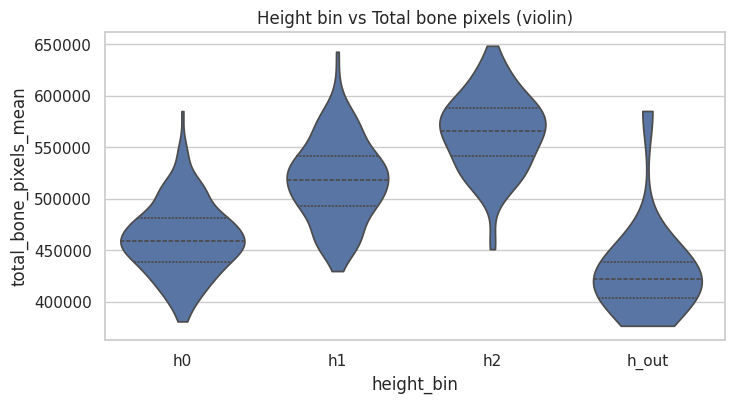

In [36]:
sns.violinplot(
    data=train_df,
    x="height_bin",
    y="total_bone_pixels_mean",
    inner="quartile",
    cut=0
)
plt.title("Height bin vs Total bone pixels (violin)")
plt.show()

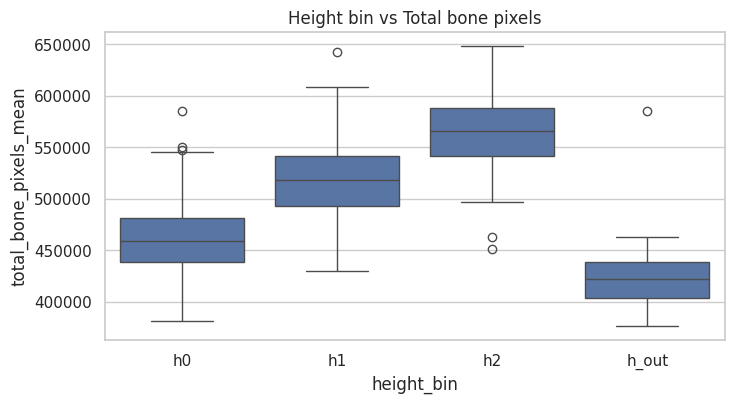

In [37]:
sns.boxplot(
    data=train_df,
    x="height_bin",
    y="total_bone_pixels_mean"
)
plt.title("Height bin vs Total bone pixels")
plt.show()

(3) height_bin vs overlap_pixels

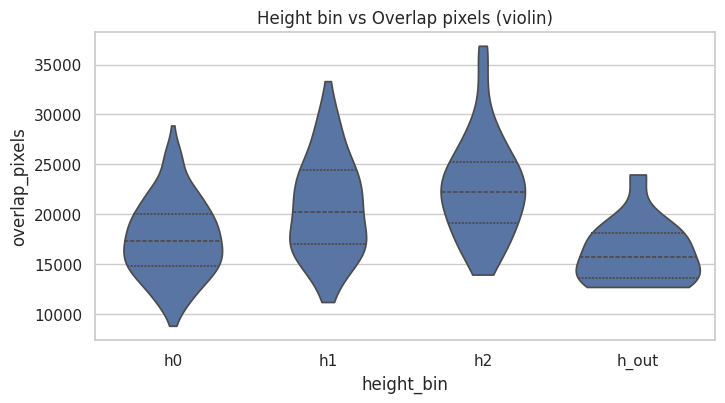

In [38]:
sns.violinplot(
    data=train_df,
    x="height_bin",
    y="overlap_pixels",
    inner="quartile",
    cut=0
)
plt.title("Height bin vs Overlap pixels (violin)")
plt.show()

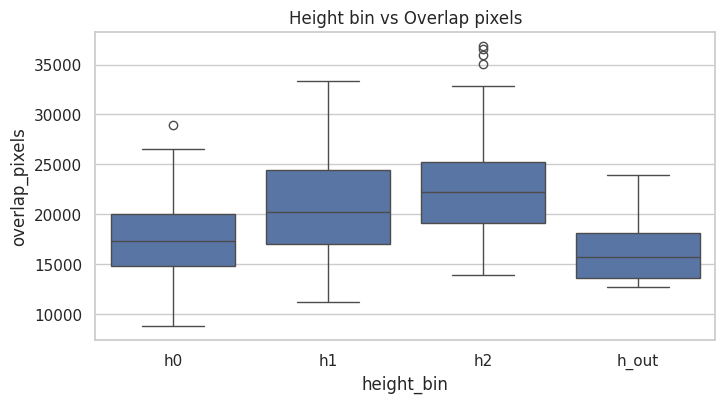

In [39]:
sns.boxplot(
    data=train_df,
    x="height_bin",
    y="overlap_pixels"
)
plt.title("Height bin vs Overlap pixels")
plt.show()

(4) height_bin × has_wrist_deviation 비율

/tmp/ipykernel_1444135/3668965071.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("height_bin")["has_wrist_deviation"]


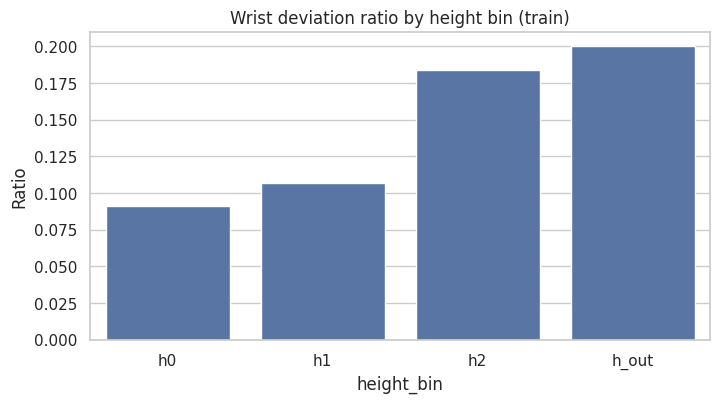

In [40]:
wd_by_height = (
    train_df
    .groupby("height_bin")["has_wrist_deviation"]
    .mean()
    .reset_index()
)

sns.barplot(
    data=wd_by_height,
    x="height_bin",
    y="has_wrist_deviation"
)
plt.title("Wrist deviation ratio by height bin (train)")
plt.ylabel("Ratio")
plt.show()

**(추가) Height bin vs non_big_bone_pixels (boxplot)**

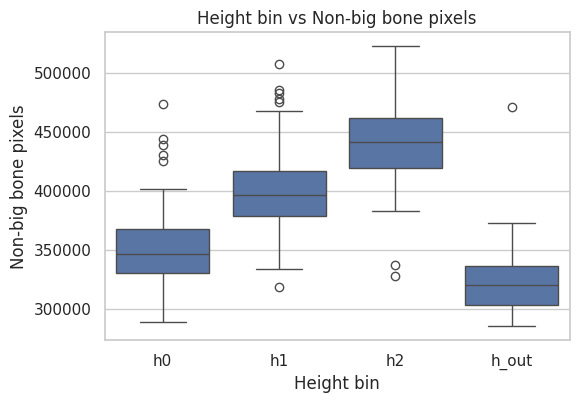

In [41]:
plt.figure(figsize=(6,4))
sns.boxplot(
    data=train_df,
    x="height_bin",
    y="non_big_bone_pixels"
)
plt.title("Height bin vs Non-big bone pixels")
plt.xlabel("Height bin")
plt.ylabel("Non-big bone pixels")
plt.show()

**(추가) Height bin × Wrist deviation × non_big_bone_pixels**

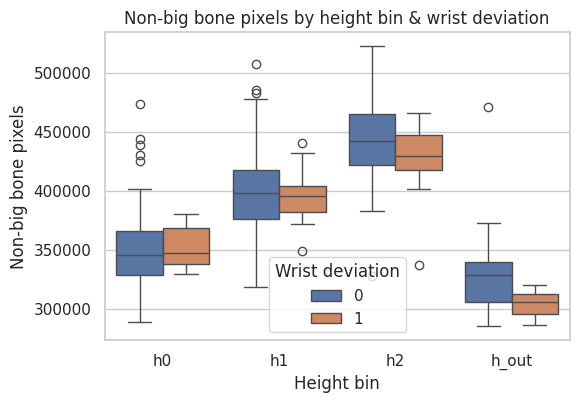

In [42]:
plt.figure(figsize=(6,4))
sns.boxplot(
    data=train_df,
    x="height_bin",
    y="non_big_bone_pixels",
    hue="has_wrist_deviation"
)
plt.title("Non-big bone pixels by height bin & wrist deviation")
plt.xlabel("Height bin")
plt.ylabel("Non-big bone pixels")
plt.legend(title="Wrist deviation")
plt.show()

**(추가) non_big_bone_pixels vs overlap_pixels (EDA 연결 확인용)**

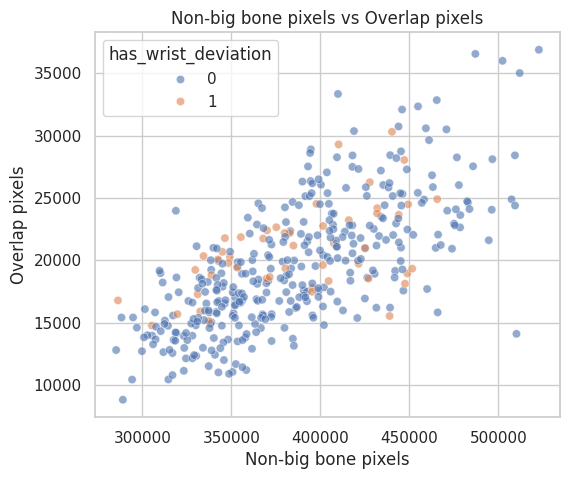

In [43]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    data=train_df,
    x="non_big_bone_pixels",
    y="overlap_pixels",
    hue="has_wrist_deviation",
    alpha=0.6
)
plt.title("Non-big bone pixels vs Overlap pixels")
plt.xlabel("Non-big bone pixels")
plt.ylabel("Overlap pixels")
plt.show()

## **SPLIT**

**1️⃣2️⃣ 1차 split (height only)**

In [44]:
train_df["stratify_key"] = train_df["height_bin"].astype(str)

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

folds_subject = {}

for fold, (tr_idx, val_idx) in enumerate(
    skf.split(train_df, train_df["stratify_key"])
):
    folds_subject[f"fold_{fold}"] = {
        "train": train_df.iloc[tr_idx]["subject_id"].tolist(),
        "val":   train_df.iloc[val_idx]["subject_id"].tolist(),
    }

In [45]:
print("\n[Train height_bin distribution]")
print(
    train_df["height_bin"]
    .value_counts()
    .sort_index()
)


[Train height_bin distribution]
height_bin
h0       175
h1       112
h2        98
h_out     15
Name: count, dtype: int64


In [46]:
if "h_out" in train_df["height_bin"].unique():
    for fold, split in folds_subject.items():
        sub = train_df[train_df["subject_id"].isin(split["val"])]
        cnt = (sub["height_bin"] == "h_out").sum()
        print(f"{fold}: h_out in val = {cnt}")

fold_0: h_out in val = 3
fold_1: h_out in val = 3
fold_2: h_out in val = 3
fold_3: h_out in val = 3
fold_4: h_out in val = 3


**1️⃣3️⃣ 사후 보정 ① nail art (최소 1)**

In [47]:
def repair_nail_subject(folds, train_df, min_cnt=1, seed=42):
    rng = np.random.default_rng(seed)
    nail_ids = set(train_df[train_df["has_nail_art"] == 1]["subject_id"])

    for fold, sp in folds.items():
        tr, va = sp["train"], sp["val"]

        if sum(s in nail_ids for s in va) >= min_cnt:
            continue

        candidates = [s for s in tr if s in nail_ids]
        rng.shuffle(candidates)

        if candidates:
            s_add = candidates[0]
            tr.remove(s_add)
            va.append(s_add)

        folds[fold]["train"] = tr
        folds[fold]["val"]   = va

    return folds

**1️⃣4️⃣ 사후 보정 ② wrist deviation 비율**

In [48]:
def repair_wrist_ratio(
    folds,
    train_df,
    target_ratio,
    tol=0.05,
    seed=42
):
    rng = np.random.default_rng(seed)

    for fold, sp in folds.items():
        tr, va = sp["train"], sp["val"]

        sub = train_df[train_df["subject_id"].isin(va)]
        ratio = sub["has_wrist_deviation"].mean()

        if abs(ratio - target_ratio) <= tol:
            continue

        wd_ids = set(train_df[train_df["has_wrist_deviation"] == 1]["subject_id"])
        non_wd_ids = set(train_df[train_df["has_wrist_deviation"] == 0]["subject_id"])

        if ratio < target_ratio:
            candidates = [s for s in tr if s in wd_ids]
        else:
            candidates = [s for s in tr if s in non_wd_ids]

        if candidates:
            s_add = rng.choice(candidates)
            tr.remove(s_add)
            va.append(s_add)

        folds[fold]["train"] = tr
        folds[fold]["val"]   = va

    return folds

**1️⃣5️⃣ 사후 보정 실행**

In [49]:
target_wd_ratio = train_df["has_wrist_deviation"].mean()

folds_subject = repair_wrist_ratio(
    folds_subject, train_df,
    target_ratio=target_wd_ratio
)

folds_subject = repair_nail_subject(
    folds_subject, train_df, min_cnt=1
)

**1️⃣6️⃣ split 저장 (subject + image)**

In [50]:
with open(os.path.join(OUT_DIR, "splits_5fold_subject.json"), "w") as f:
    json.dump(folds_subject, f, indent=2)

for fold, sp in folds_subject.items():
    train_imgs = eda_df[eda_df["subject_id"].isin(sp["train"])]["image_id"]
    val_imgs   = eda_df[eda_df["subject_id"].isin(sp["val"])]["image_id"]

    train_imgs.to_csv(os.path.join(OUT_DIR, f"{fold}_train.txt"), index=False, header=False)
    val_imgs.to_csv(os.path.join(OUT_DIR, f"{fold}_val.txt"), index=False, header=False)

In [51]:
for fold, split in folds_subject.items():
    train_imgs = eda_df[
        eda_df["subject_id"].isin(split["train"])
    ]["image_id"]

    val_imgs = eda_df[
        eda_df["subject_id"].isin(split["val"])
    ]["image_id"]

    print(
        f"[{fold}] "
        f"train_images = {len(train_imgs):4d}, "
        f"val_images = {len(val_imgs):4d}"
    )

[fold_0] train_images =  638, val_images =  160
[fold_1] train_images =  639, val_images =  159
[fold_2] train_images =  639, val_images =  159
[fold_3] train_images =  634, val_images =  164
[fold_4] train_images =  638, val_images =  160


## **SPLIT fold별 시각화**

(A) fold별 height_bin 분포 (val vs test)

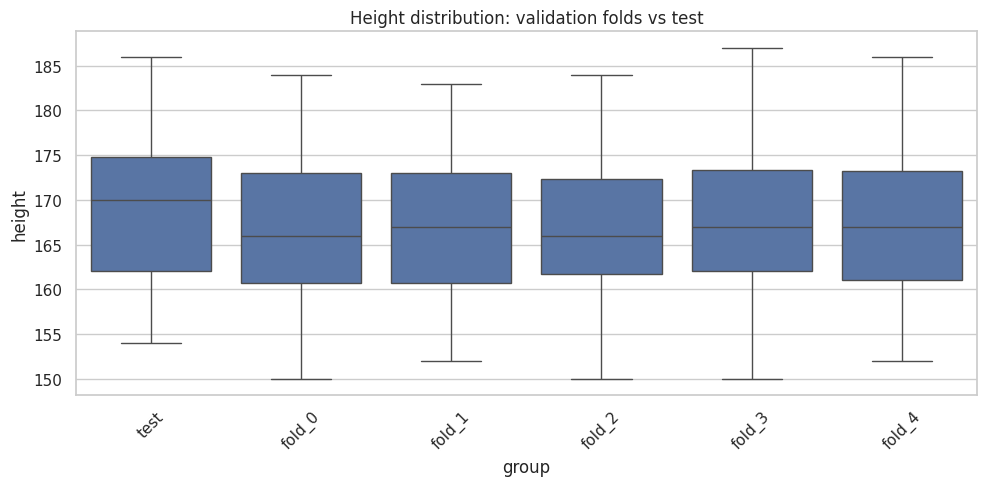

In [31]:
records = []

# test
for h in test_df["height"]:
    records.append({
        "group": "test",
        "height": h
    })

# validation (fold별)
for fold, split in folds_subject.items():
    val_sub = train_df[
        train_df["subject_id"].isin(split["val"])
    ]
    for h in val_sub["height"]:
        records.append({
            "group": fold,
            "height": h
        })

plot_df = pd.DataFrame(records)

plt.figure(figsize=(10,5))
sns.boxplot(
    data=plot_df,
    x="group",
    y="height"
)
plt.title("Height distribution: validation folds vs test")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [32]:
pd.crosstab(meta_df["split"], meta_df["height_bin"], normalize="index")

height_bin,h0,h1,h2,h_out
split,,,,
test,0.373333,0.346667,0.280,0.0000
train,0.437500,0.280000,0.245,0.0375


In [33]:
for fold, split in folds_subject.items():
    print(f"\n{fold}")
    sub = train_df[train_df["subject_id"].isin(split["val"])]
    print(sub["height_bin"].value_counts(normalize=True))


fold_0
height_bin
h0       0.4375
h1       0.2875
h2       0.2375
h_out    0.0375
Name: proportion, dtype: float64

fold_1
height_bin
h0       0.4375
h1       0.2875
h2       0.2375
h_out    0.0375
Name: proportion, dtype: float64

fold_2
height_bin
h0       0.4375
h1       0.2750
h2       0.2500
h_out    0.0375
Name: proportion, dtype: float64

fold_3
height_bin
h0       0.439024
h1       0.280488
h2       0.243902
h_out    0.036585
Name: proportion, dtype: float64

fold_4
height_bin
h0       0.4375
h1       0.2750
h2       0.2500
h_out    0.0375
Name: proportion, dtype: float64


(B) fold별 has_wrist_deviation 비율 확인 (핵심)

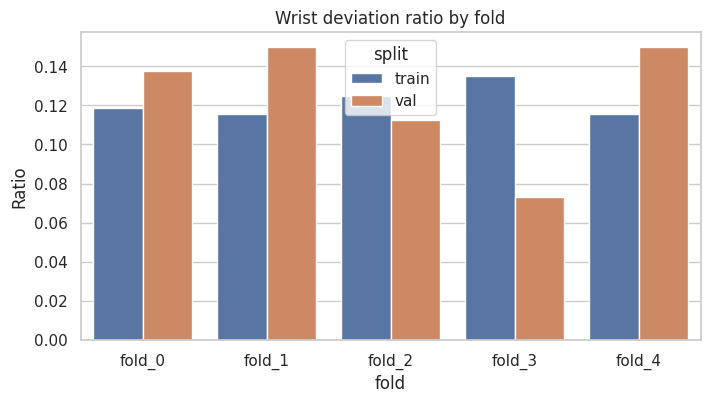

In [34]:
records = []

for fold, split in folds_subject.items():
    for part in ["train", "val"]:
        sub = train_df[
            train_df["subject_id"].isin(split[part])
        ]
        records.append({
            "fold": fold,
            "split": part,
            "wd_ratio": sub["has_wrist_deviation"].mean(),
            "count": len(sub)
        })

wd_fold_df = pd.DataFrame(records)

sns.barplot(
    data=wd_fold_df,
    x="fold",
    y="wd_ratio",
    hue="split"
)
plt.title("Wrist deviation ratio by fold")
plt.ylabel("Ratio")
plt.show()

(C) height_bin × has_wrist_deviation (fold별 heatmap)

/tmp/ipykernel_1425286/1681650433.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["height_bin", "has_wrist_deviation"])


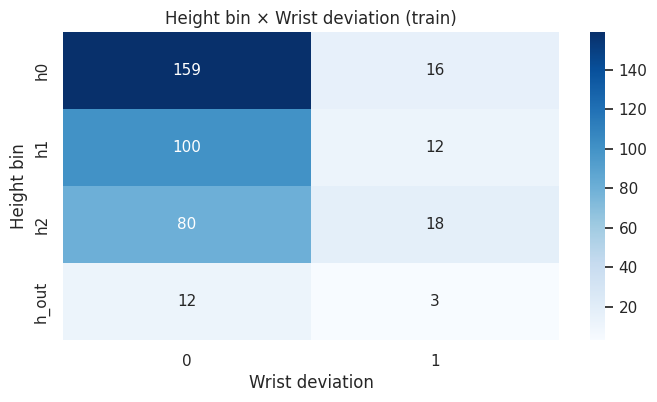

In [35]:
pivot_df = (
    train_df
    .assign(fold="all")
    .groupby(["height_bin", "has_wrist_deviation"])
    .size()
    .reset_index(name="count")
)

pivot_table = pivot_df.pivot(
    index="height_bin",
    columns="has_wrist_deviation",
    values="count"
)

sns.heatmap(
    pivot_table,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Height bin × Wrist deviation (train)")
plt.xlabel("Wrist deviation")
plt.ylabel("Height bin")
plt.show()

**(추가) fold별 분포가 진짜 비슷한지(non_big_bone_pixels, overlap_pixels, boundary_adj_pixels) 비교**

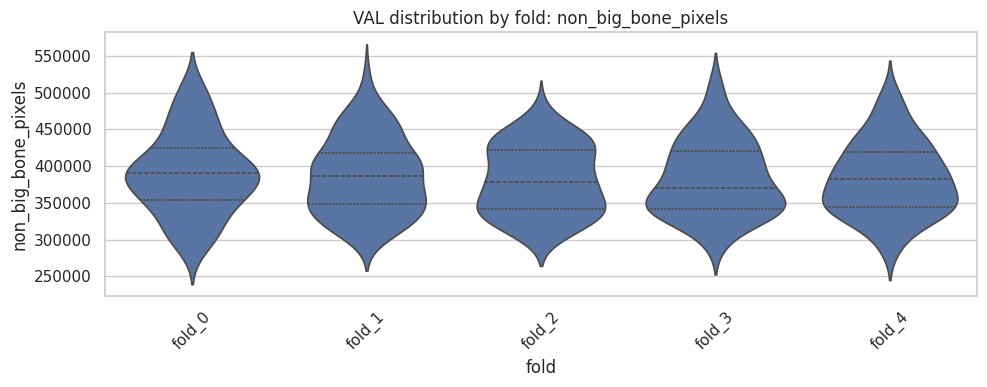

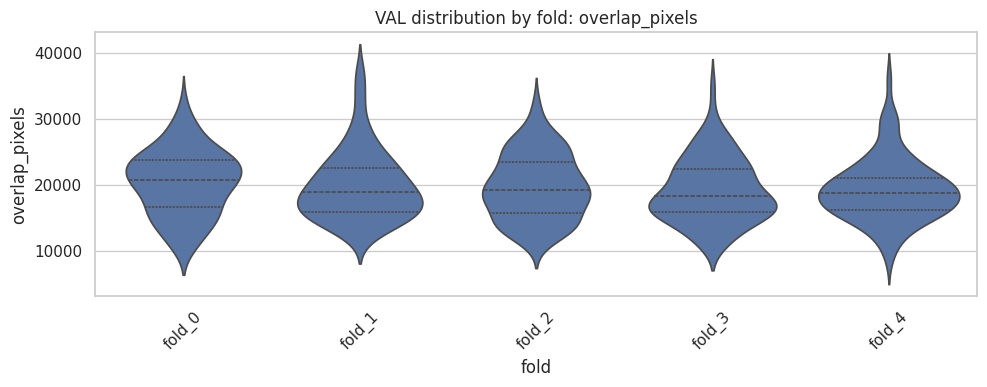

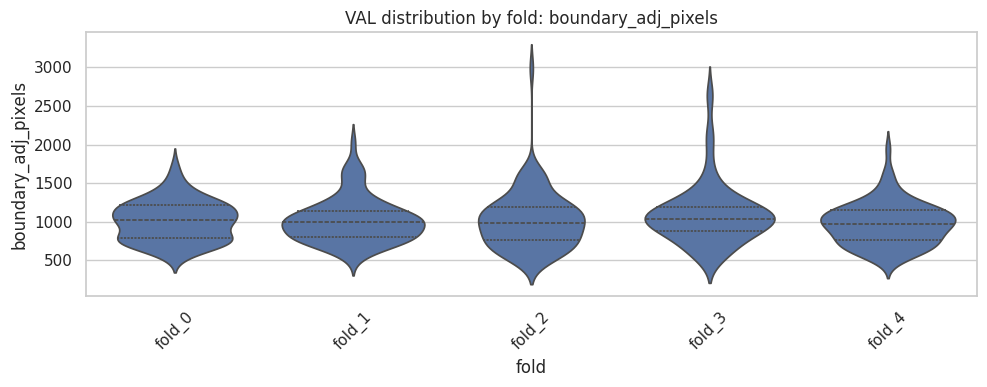

In [52]:
# Cell 17 이후(또는 마지막) 추천: fold별 val 분포 비교
metrics = ["non_big_bone_pixels", "overlap_pixels", "boundary_adj_pixels"]

rows = []
for fold, sp in folds_subject.items():
    val_sub = train_df[train_df["subject_id"].isin(sp["val"])].copy()
    val_sub["fold"] = fold
    rows.append(val_sub)

val_all = pd.concat(rows, axis=0)

for m in metrics:
    plt.figure(figsize=(10,4))
    sns.violinplot(data=val_all, x="fold", y=m, inner="quartile")
    plt.title(f"VAL distribution by fold: {m}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

**(추가) hard 샘플(top 10%)이 fold마다 골고루 들어갔나?**

,fold,hard_overlap_ratio,hard_boundary_ratio,wd_ratio,n
0,fold_0,0.112500,0.075000,0.137500,80
1,fold_1,0.100000,0.100000,0.150000,80
2,fold_2,0.112500,0.125000,0.112500,80
3,fold_3,0.097561,0.134146,0.073171,82
4,fold_4,0.075000,0.075000,0.150000,80


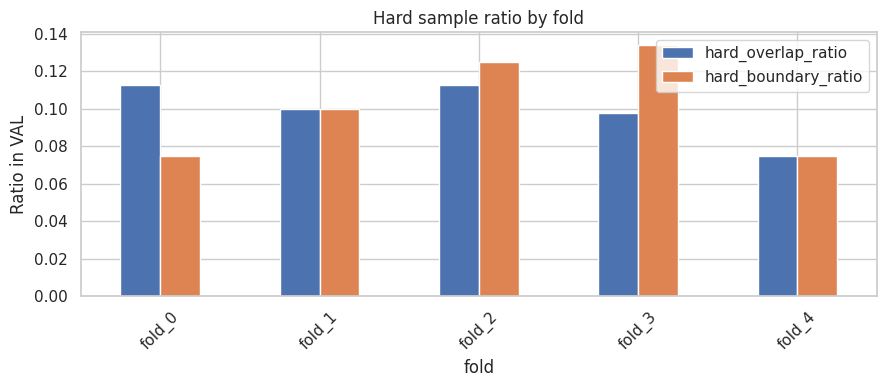

In [53]:
q = 0.9
train_df["hard_overlap"]  = train_df["overlap_pixels"] >= train_df["overlap_pixels"].quantile(q)
train_df["hard_boundary"] = train_df["boundary_adj_pixels"] >= train_df["boundary_adj_pixels"].quantile(q)

rows = []
for fold, sp in folds_subject.items():
    val_sub = train_df[train_df["subject_id"].isin(sp["val"])].copy()
    rows.append({
        "fold": fold,
        "hard_overlap_ratio": val_sub["hard_overlap"].mean(),
        "hard_boundary_ratio": val_sub["hard_boundary"].mean(),
        "wd_ratio": val_sub["has_wrist_deviation"].mean(),
        "n": len(val_sub)
    })
hard_fold_df = pd.DataFrame(rows)

display(hard_fold_df)

hard_fold_df.set_index("fold")[["hard_overlap_ratio","hard_boundary_ratio"]].plot(kind="bar", figsize=(9,4))
plt.ylabel("Ratio in VAL")
plt.title("Hard sample ratio by fold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**(추가) overlap-boundary 관계가 조건부로 바뀌는지(키/스케일 통제 후)**

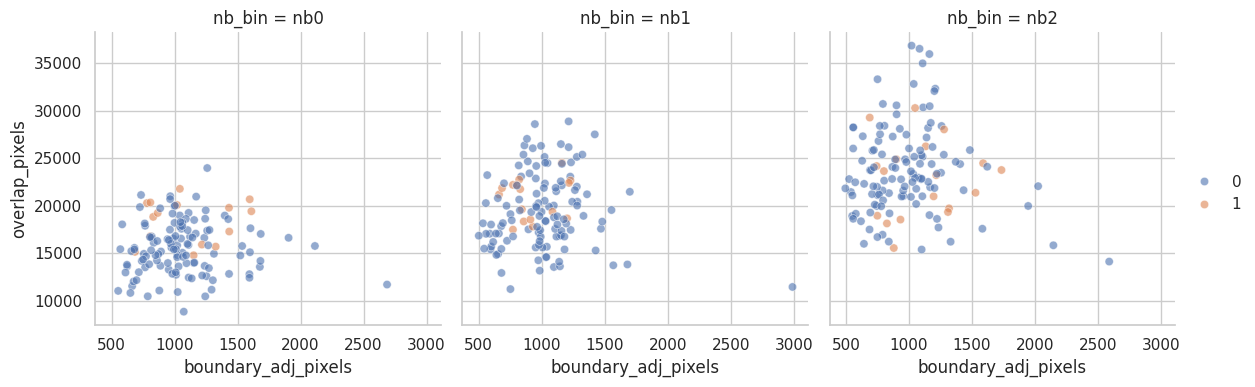

In [54]:
# non_big_bone_pixels를 3분위로 나눈 뒤 scatter
train_df["nb_bin"] = pd.qcut(train_df["non_big_bone_pixels"], q=3, labels=["nb0","nb1","nb2"])

g = sns.FacetGrid(train_df, col="nb_bin", height=4, sharex=True, sharey=True)
g.map_dataframe(sns.scatterplot, x="boundary_adj_pixels", y="overlap_pixels", hue="has_wrist_deviation", alpha=0.6)
g.add_legend()
plt.show()

**(추가) wrist deviation이 “스케일 대비” overlap을 올리는지(잔차 확인)**

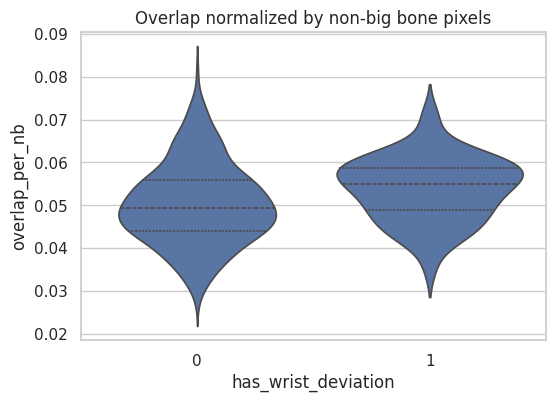

In [55]:
# 간단 잔차: overlap / non_big_bone_pixels (정규화 지표)
train_df["overlap_per_nb"] = train_df["overlap_pixels"] / (train_df["non_big_bone_pixels"] + 1e-6)

plt.figure(figsize=(6,4))
sns.violinplot(data=train_df, x="has_wrist_deviation", y="overlap_per_nb", inner="quartile")
plt.title("Overlap normalized by non-big bone pixels")
plt.show()

**(추가) label-noise 후보(극단치) top-k 시각 점검 리스트**

In [56]:
topk = 15
print("Top overlap images:")
display(eda_df.sort_values("overlap_pixels", ascending=False)[["subject_id","image_id","overlap_pixels","boundary_adj_pixels","has_wrist_deviation"]].head(topk))

print("Top boundary images:")
display(eda_df.sort_values("boundary_adj_pixels", ascending=False)[["subject_id","image_id","boundary_adj_pixels","overlap_pixels","has_wrist_deviation"]].head(topk))

Top overlap images:


,subject_id,image_id,overlap_pixels,boundary_adj_pixels,has_wrist_deviation
573,ID436,image1666060373215.png,39090,1040,0
721,ID510,image1666747919852.png,38272,1154,0
605,ID452,image1666573675084.png,37847,1009,0
391,ID344,image1664932490676.png,37357,954,0
390,ID344,image1664932510436.png,36392,1088,0
382,ID340,image1664932097820.png,35369,1303,0
720,ID510,image1666747903675.png,34818,1015,0
609,ID454,image1666573854736.png,34535,967,0
606,ID452,image1666573702766.png,34131,1316,0
447,ID373,image1665452035077.png,33658,724,0


Top boundary images:


,subject_id,image_id,boundary_adj_pixels,overlap_pixels,has_wrist_deviation
171,ID097,image1661823399448.png,3146,10779,0
170,ID097,image1661823372660.png,2834,12107,0
71,ID036,image1661318659827.png,2794,9223,0
98,ID060,image1661393400879.png,2598,11361,0
99,ID060,image1661393384829.png,2581,16872,0
70,ID036,image1661318687383.png,2579,14168,0
132,ID078,image1661737218472.png,2330,14440,0
486,ID392,image1665537659557.png,2243,15419,0
794,ID547,image1667353928376.png,2047,25360,0
483,ID391,image1665537597286.png,2043,12994,0
